In [45]:
# Importar bibliotecas
import zipfile
from numpy import info
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Instanciar o LabelEncoder
le = LabelEncoder()

In [46]:
# Importa arquivos processados

with zipfile.ZipFile("dados_processados.zip", "r") as zip_ref:
    zip_ref.extractall()

In [47]:
# Carrega bases de treino, validação e teste

X_treino_df = pd.read_csv('X_treino.csv')
display(X_treino_df.head())
y_treino_df = pd.read_csv('y_treino.csv')
display(y_treino_df.head())
X_teste_df = pd.read_csv('X_teste.csv')
display(X_teste_df.head())
y_teste_df = pd.read_csv('y_teste.csv')
display(y_teste_df.head())
X_val_df = pd.read_csv('X_val.csv')
display(X_val_df.head())
y_val_df = pd.read_csv('y_val.csv')
display(y_val_df.head())

# Criar um novo DataFrame empilhando X_treino_df e X_val_df (formato melhor para o MLP)
X_treino_val_df = pd.concat([X_treino_df, X_val_df], ignore_index=True)
display(X_treino_val_df.head())
print(f"Shape de X_treino_val_df: {X_treino_val_df.shape}")

y_treino_val_df = pd.concat([y_treino_df, y_val_df], ignore_index=True)
display(y_treino_val_df.head())
print(f"Shape de y_treino_val_df: {y_treino_val_df.shape}")

,historical_tickets,sla_hours,resolution_time_hours,image_width,image_height,sentiment_score,num_words,num_images_x,latitude,longitude,...,priority_Baixa,priority_Crítica,priority_Média,status_Aberto,status_Em andamento,status_Fechado,assigned_team_Aplicações,assigned_team_Infra,assigned_team_N1,assigned_team_N2
0,-0.501715,-0.704413,0.815095,-0.478589,-0.491344,-1.022203,-0.214642,-1.332575,-0.497740,0.468707,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.090169,-0.704413,-0.145479,-0.478589,-0.491344,1.726922,0.628414,-1.332575,-1.099546,0.591982,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.851164,-0.704413,1.631582,-2.068180,3.116287,-0.405931,1.471469,-1.332575,1.625253,-1.530947,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,1.443048,-0.957453,-0.673794,0.527254,0.454713,-0.784645,-0.214642,0.436878,-0.960263,0.135556,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.005614,-0.704413,-1.682396,-0.478589,-0.491344,-1.010153,-1.900753,-1.332575,-0.970147,-1.230824,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


,target_category
0,RH
1,Rede
2,RH
3,Acesso
4,Acesso


,historical_tickets,sla_hours,resolution_time_hours,image_width,image_height,sentiment_score,num_words,num_images_x,latitude,longitude,...,priority_Baixa,priority_Crítica,priority_Média,status_Aberto,status_Em andamento,status_Fechado,assigned_team_Aplicações,assigned_team_Infra,assigned_team_N1,assigned_team_N2
0,1.443048,-0.957453,1.631582,-0.478589,-0.466116,-0.905146,0.628414,-1.332575,-0.499889,-0.862983,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-0.248050,-0.957453,0.959181,-0.478589,-0.491344,-1.416410,-0.214642,1.321605,-0.642435,1.543005,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-0.417160,-0.451373,1.679611,0.527254,-0.352589,0.673407,0.628414,-0.447849,0.188006,0.234262,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.443048,0.307747,1.631582,-0.478589,-0.491344,1.646015,0.628414,0.436878,-0.168067,-0.835777,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1.696713,-0.451373,0.046636,-2.068180,3.116287,1.219100,-0.214642,-0.447849,-1.153210,0.610305,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


,target_category
0,Hardware
1,Rede
2,Financeiro
3,Software
4,Acesso


,historical_tickets,sla_hours,resolution_time_hours,image_width,image_height,sentiment_score,num_words,num_images_x,latitude,longitude,...,priority_Baixa,priority_Crítica,priority_Média,status_Aberto,status_Em andamento,status_Fechado,assigned_team_Aplicações,assigned_team_Infra,assigned_team_N1,assigned_team_N2
0,0.343834,0.307747,-0.769852,0.527254,0.454713,0.225835,0.628414,-0.447849,0.394727,-0.820039,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.343834,0.307747,1.199324,-0.478589,-0.491344,-0.309530,-1.900753,-1.332575,1.491850,1.541550,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-1.178155,0.307747,0.094665,-0.478589,-0.491344,1.048678,-1.057698,1.321605,0.219069,1.114016,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-1.262710,1.825988,-0.241536,-0.478589,-0.491344,0.828335,-1.900753,-0.447849,0.421708,-0.112720,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,-1.009045,1.825988,-1.586339,-0.478589,-0.377817,0.917850,0.628414,1.321605,-0.267724,1.674138,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


,target_category
0,RH
1,Software
2,Software
3,Acesso
4,Rede


,historical_tickets,sla_hours,resolution_time_hours,image_width,image_height,sentiment_score,num_words,num_images_x,latitude,longitude,...,priority_Baixa,priority_Crítica,priority_Média,status_Aberto,status_Em andamento,status_Fechado,assigned_team_Aplicações,assigned_team_Infra,assigned_team_N1,assigned_team_N2
0,-0.501715,-0.704413,0.815095,-0.478589,-0.491344,-1.022203,-0.214642,-1.332575,-0.497740,0.468707,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.090169,-0.704413,-0.145479,-0.478589,-0.491344,1.726922,0.628414,-1.332575,-1.099546,0.591982,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.851164,-0.704413,1.631582,-2.068180,3.116287,-0.405931,1.471469,-1.332575,1.625253,-1.530947,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,1.443048,-0.957453,-0.673794,0.527254,0.454713,-0.784645,-0.214642,0.436878,-0.960263,0.135556,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.005614,-0.704413,-1.682396,-0.478589,-0.491344,-1.010153,-1.900753,-1.332575,-0.970147,-1.230824,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


Shape de X_treino_val_df: (4000, 51)


,target_category
0,RH
1,Rede
2,RH
3,Acesso
4,Acesso


Shape de y_treino_val_df: (4000, 1)


In [48]:
# Ajustar (fit) o LabelEncoder aos dados de treino e validação combinados
# Isso faz com que o LabelEncoder aprenda todas as categorias únicas de 'target_category'
le.fit(y_treino_val_df['target_category'])

# Aplicar o LabelEncoder à coluna 'target_category' de y_treino_val_df
y_treino_val_df['target_category'] = le.transform(y_treino_val_df['target_category'])
display(y_treino_val_df.head())

y_teste_df['target_category'] = le.transform(y_teste_df['target_category'])
display(y_teste_df.head())

y_val_df['target_category'] = le.transform(y_val_df['target_category'])
display(y_val_df.head())



,target_category
0,3
1,4
2,3
3,0
4,0


,target_category
0,2
1,4
2,1
3,5
4,0


,target_category
0,3
1,5
2,5
3,0
4,4


In [50]:
# Criar MLPClassifier

# mlp = MLPClassifier: Inicializa um classificador de Perceptron Multicamadas.
#   hidden_layer_sizes=(128, 64): duas camadas ocultas: a primeira com 128 neurônios e a segunda com 64 neurônios.
#   activation='relu': Função de ativação para as camadas ocultas (Rectified Linear Unit).
#   alpha=0.0001: Parâmetro de regularização L2 (termo de penalidade de peso).
#   batch_size=200: Tamanho dos mini-lotes para otimização.
#   max_iter=50: Número máximo de épocas (iterações completas sobre o conjunto de dados de treino).
#   early_stopping=True: Habilita a parada antecipada.
#   validation_fraction=0.1: 10% dos dados de treino são reservados para validação.
#   n_iter_no_change=10: Número de épocas sem melhoria na pontuação de validação para acionar a parada antecipada.
#   verbose=True: Ativa a saída detalhada durante o treinamento, mostrando o progresso da perda.
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=200,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

# Treinar o modelo MLP com os dados transformados
# Certifique-se de que y_treino_df['target_category'] é uma série 1D
mlp.fit(X_treino_val_df, y_treino_val_df['target_category'])

print("Modelo MLP treinado com sucesso!")

Iteration 1, loss = 1.79011753
Validation score: 0.270000
Iteration 2, loss = 1.68310405
Validation score: 0.300000
Iteration 3, loss = 1.59649493
Validation score: 0.342500
Iteration 4, loss = 1.53020870
Validation score: 0.377500
Iteration 5, loss = 1.48250342
Validation score: 0.390000
Iteration 6, loss = 1.44445932
Validation score: 0.397500
Iteration 7, loss = 1.41266433
Validation score: 0.387500
Iteration 8, loss = 1.38185569
Validation score: 0.405000
Iteration 9, loss = 1.35265255
Validation score: 0.395000
Iteration 10, loss = 1.32385436
Validation score: 0.410000
Iteration 11, loss = 1.29109707
Validation score: 0.435000
Iteration 12, loss = 1.25923526
Validation score: 0.427500
Iteration 13, loss = 1.23042233
Validation score: 0.445000
Iteration 14, loss = 1.20309768
Validation score: 0.445000
Iteration 15, loss = 1.17500311
Validation score: 0.410000
Iteration 16, loss = 1.15280259
Validation score: 0.440000
Iteration 17, loss = 1.12893327
Validation score: 0.432500
Iterat

In [51]:
# Métricas finais
y_pred = mlp.predict(X_teste_df)
accuracy = accuracy_score(y_teste_df, y_pred)
print(f"Acurácia no teste: {accuracy:.4f}")
print(f"Número de iterações realizadas: {mlp.n_iter_}")
print(f"Perda final (loss): {mlp.loss_}")

Acurácia no teste: 0.4690
Número de iterações realizadas: 24
Perda final (loss): 0.9858951794404128


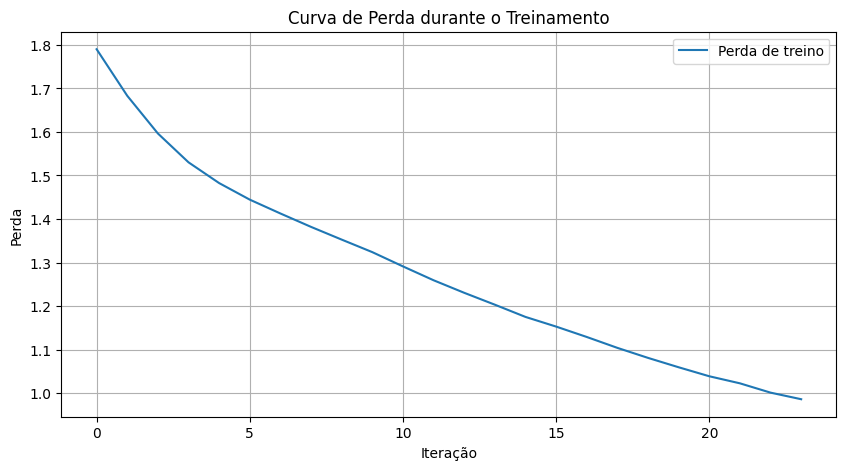

In [53]:
# Plotar a loss curve
plt.figure(figsize=(10, 5))
plt.plot(mlp.loss_curve_, label='Perda de treino')
plt.xlabel('Iteração')
plt.ylabel('Perda')
plt.title('Curva de Perda durante o Treinamento')
plt.grid(True)
plt.legend()
plt.show()

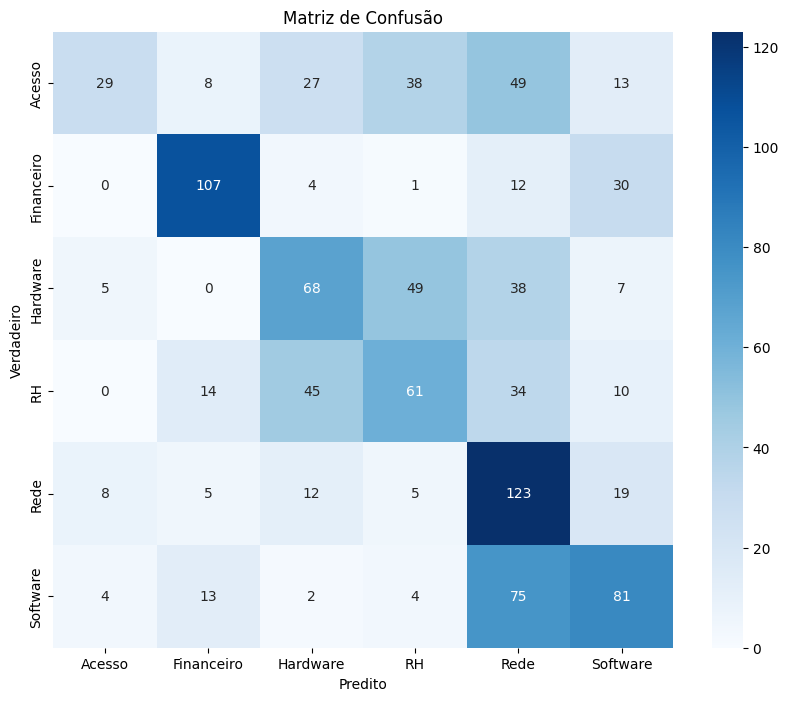


Métricas de avaliação:

              precision    recall  f1-score   support

      Acesso       0.63      0.18      0.28       164
  Financeiro       0.73      0.69      0.71       154
    Hardware       0.43      0.41      0.42       167
          RH       0.39      0.37      0.38       164
        Rede       0.37      0.72      0.49       172
    Software       0.51      0.45      0.48       179

    accuracy                           0.47      1000
   macro avg       0.51      0.47      0.46      1000
weighted avg       0.51      0.47      0.46      1000



In [56]:
# Matriz de confusão
# y_teste_df['target_category'] já está transformado em numérico, então podemos usá-lo diretamente
y_teste_transformed = y_teste_df['target_category']

# Obter os nomes das classes para o heatmap e relatório
class_names = le.classes_

cm = confusion_matrix(y_teste_transformed, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

# Métricas de avaliação
print("\nMétricas de avaliação:\n")
print(classification_report(y_teste_transformed, y_pred, target_names=class_names))

## Conclusões dessa versão

Realizamo treinamento e avaliação de um modelo de Multi-layer Perceptron (MLP) para classificação.

**Avaliação do Modelo**:
  *   **Acurácia**: O modelo alcançou uma acurácia de **46.90%** no conjunto de teste.
  *   **Curva de Perda**: A análise da curva de perda durante o treinamento mostrou uma convergência gradual.
  *   **Matriz de Confusão e Métricas**: Observou-se que algumas classes, como 'Financeiro' e 'Rede', tiveram um desempenho melhor em termos de recall e precisão, enquanto outras, como 'Acesso', apresentaram com baixos recall e f1-score.

### Próximos Passos

*   **Otimização de Hiperparâmetros**
*   **Engenharia de Features**
*   **Outros Modelos**

